# Evolución de los Modelos de Lenguaje

**Duración estimada:** ~1.5 horas  
**Nivel:** Intermedio  
**Lectura complementaria:** `evolucion_modelos_lenguaje.md`

---

## Agenda

| Bloque | Tema |
|--------|------|
| 1 | SLM — Statistical Language Models (n-gramas, suavizado, limitaciones) |
| 2 | NLM — Neural Language Models (word2vec, representaciones distribuidas) |
| 3 | PLM — Pre-trained Language Models (ELMo, BERT, GPT) |
| 4 | LLM — Large Language Models (scaling, emergent abilities, in-context learning) |

> Las **scaling laws** (ley KM y ley Chinchilla) se estudian en profundidad en el notebook hermano `../04_scaling_laws/04_scaling_laws.ipynb`.

Este notebook es **ejecutable** de principio a fin. Los bloques de PLM/LLM muestran ideas con ejemplos pequeños — para consultar toda la teoría, revisa el `.md`.

---
## 0. Instalación de dependencias

In [1]:
!uv pip install nltk scikit-learn matplotlib numpy pandas gensim datasets transformers torch

Using Python 3.11.13 environment at: /home/robert/Documents/Trabajo/Semillero investigación/introduccion_al_nlp/.venv
Resolved 87 packages in 515ms                                        
⠙ Preparing packages... (0/2)                                                   
⠙ Preparing packages... (0/2)--------------     0 B/48.82 KiB           
⠙ Preparing packages... (0/2)-------------- 16.00 KiB/48.82 KiB         
⠙ Preparing packages... (0/2)---------- 32.00 KiB/48.82 KiB         
⠙ Preparing packages... (0/2)---------- 48.00 KiB/48.82 KiB         
⠙ Preparing packages... (0/2)0/2)                                                   
⠙ Preparing packages... (0/2)--------------     0 B/9.76 MiB            
⠙ Preparing packages... (0/2)-------------- 14.78 KiB/9.76 MiB          
⠙ Preparing packages... (0/2)-------------- 30.78 KiB/9.76 MiB          
⠙ Preparing packages... (0/2)-------------- 46.78 KiB/9.76 MiB          
⠙ Preparing packages... (0/2)-------------- 62.78 KiB/9.76 MiB        

In [20]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

import math
import random
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
print('Librerías listas.')

Librerías listas.


---
## 1. SLM — Statistical Language Models

Un **modelo de lenguaje** asigna probabilidad a una secuencia de palabras:

$$P(w_1, w_2, \dots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, \dots, w_{t-1})$$

Los **SLM** lo aproximan con la **suposición de Markov**: solo los últimos `n-1` tokens importan. Resultado: **n-gramas**.

- Unigrama (n=1): cada palabra es independiente.
- Bigrama (n=2): depende de la anterior.
- Trigrama (n=3): depende de las dos anteriores.

### 1.1 Un corpus de juguete

In [3]:
from nltk.tokenize import word_tokenize

corpus = [
    'el gato come pescado',
    'el perro come carne',
    'el gato duerme en el sofa',
    'el perro duerme en la cama',
    'el gato come croquetas',
    'el perro come croquetas',
    'el gato juega con la pelota',
    'el perro juega con el hueso',
]

tokens_corpus = [['<s>'] + word_tokenize(s, language='spanish') + ['</s>'] for s in corpus]
for t in tokens_corpus[:3]:
    print(t)

['<s>', 'el', 'gato', 'come', 'pescado', '</s>']
['<s>', 'el', 'perro', 'come', 'carne', '</s>']
['<s>', 'el', 'gato', 'duerme', 'en', 'el', 'sofa', '</s>']


### 1.2 Estimación por máxima verosimilitud (MLE)

$$P(w_t \mid w_{t-1}) = \frac{\text{count}(w_{t-1}, w_t)}{\text{count}(w_{t-1})}$$

In [21]:
def entrenar_bigramas(tokens_list):
    unigram = Counter()
    bigram = Counter()
    for tokens in tokens_list:
        unigram.update(tokens)
        bigram.update(zip(tokens[:-1], tokens[1:]))
    return unigram, bigram

unigram, bigram = entrenar_bigramas(tokens_corpus)

def prob_bigrama_mle(w_prev, w, unigram, bigram):
    if unigram[w_prev] == 0:
        return 0.0
    return bigram[(w_prev, w)] / unigram[w_prev]

for (w1, w2) in [('el', 'gato'), ('gato', 'come'), ('perro', 'duerme'), ('gato', 'vuela')]:
    p = prob_bigrama_mle(w1, w2, unigram, bigram)
    print(f'P({w2:<10} | {w1:<6}) = {p:.3f}')

P(gato       | el    ) = 0.400
P(come       | gato  ) = 0.500
P(duerme     | perro ) = 0.250
P(vuela      | gato  ) = 0.000


Ojo a `P(vuela | gato) = 0.000`. Como nunca vimos ese bigrama, una sola aparición condena a cero toda la probabilidad de la oración. Esto es **data sparsity**.

### 1.3 Suavizado Laplace (add-k)

$$P_{\text{add-k}}(w \mid w_{t-1}) = \frac{\text{count}(w_{t-1}, w) + k}{\text{count}(w_{t-1}) + k \cdot V}$$

Suma una constante pequeña a todo — ahora nada tiene probabilidad cero.

In [5]:
V = len(unigram)

def prob_bigrama_laplace(w_prev, w, unigram, bigram, k=1.0, V=V):
    return (bigram[(w_prev, w)] + k) / (unigram[w_prev] + k * V)

print(f"Vocabulario V = {V}\n")
print(f"{'w_prev':<8} {'w':<12} {'MLE':>8} {'Laplace(k=1)':>14}")
print('-' * 44)
for (w1, w2) in [('el', 'gato'), ('gato', 'vuela'), ('el', 'dragon'), ('perro', 'come')]:
    mle = prob_bigrama_mle(w1, w2, unigram, bigram)
    lap = prob_bigrama_laplace(w1, w2, unigram, bigram, k=1.0)
    print(f'{w1:<8} {w2:<12} {mle:>8.3f} {lap:>14.4f}')

Vocabulario V = 18

w_prev   w                 MLE   Laplace(k=1)
--------------------------------------------
el       gato            0.400         0.1786
gato     vuela           0.000         0.0455
el       dragon          0.000         0.0357
perro    come            0.500         0.1364


### 1.4 Generar texto con un SLM

Un LM **también sirve para generar**: muestreamos token a token.

In [22]:
def generar_slm(unigram, bigram, k=1.0, max_tokens=20):
    vocab = list(unigram.keys())
    actual = '<s>'
    generado = []
    for _ in range(max_tokens):
        probs = np.array([prob_bigrama_laplace(actual, w, unigram, bigram, k=k) for w in vocab])
        probs = probs / probs.sum()
        siguiente = np.random.choice(vocab, p=probs)
        if siguiente == '</s>':
            break
        if siguiente != '<s>':
            generado.append(siguiente)
        actual = siguiente
    return ' '.join(generado)

print('=== Frases generadas con un bigrama + Laplace ===')
for _ in range(5):
    print(' •', generar_slm(unigram, bigram))

=== Frases generadas con un bigrama + Laplace ===
 • el hueso cama sofa gato come el con la croquetas hueso juega pescado come pescado
 • 
 • come
 • carne gato pescado
 • come croquetas come en sofa carne come el hueso hueso juega perro gato cama carne gato duerme con


### 1.5 Perplejidad: ¿qué tan bueno es el modelo?

La **perplejidad** mide qué tan "sorprendido" está el modelo frente a un texto real — más bajo es mejor.

$$\text{PP}(w_1, \dots, w_T) = \exp\left(-\frac{1}{T}\sum_{t=1}^{T} \log P(w_t \mid w_{t-1})\right)$$

In [23]:
def perplejidad(tokens, unigram, bigram, k=1.0):
    log_p = 0.0
    N = 0
    for i in range(1, len(tokens)):
        p = prob_bigrama_laplace(tokens[i-1], tokens[i], unigram, bigram, k=k)
        log_p += math.log(p + 1e-12)
        N += 1
    return math.exp(-log_p / N)

oraciones_prueba = [
    'el gato come pescado',
    'el perro juega con la pelota',
    'el dragon vuela sobre castillos',
]
for s in oraciones_prueba:
    toks = ['<s>'] + word_tokenize(s, language='spanish') + ['</s>']
    pp = perplejidad(toks, unigram, bigram, k=1.0)
    print(f'PP = {pp:8.2f} | {s}')

PP =     6.59 | el gato come pescado
PP =     7.32 | el perro juega con la pelota
PP =    14.28 | el dragon vuela sobre castillos


### 1.6 Limitaciones de los SLM

- **Ventana muy corta**: solo ven 2–5 tokens atrás.
- **Dispersión**: la mayor parte de n-gramas nunca aparece en el corpus.
- **Sin semántica**: "perro" y "can" son símbolos distintos, sin relación.
- **Escalabilidad**: número de n-gramas crece exponencialmente con `n`.

La solución: **representaciones densas**.

---
## 2. NLM — Neural Language Models

Idea central (Bengio et al., 2003): **aprender a la vez** un embedding por palabra y un modelo que predice la siguiente usando esos embeddings. Palabras semánticamente parecidas terminan con vectores parecidos y el modelo generaliza.

### 2.1 Word2Vec — una demo rápida

Entrenamos skip-gram sobre un corpus ligeramente mayor para ver relaciones semánticas emergentes.

In [24]:
from gensim.models import Word2Vec

corpus_w2v = [
    'el gato come pescado fresco',
    'el perro come carne asada',
    'la gata duerme sobre el sofa',
    'el perro juega con la pelota',
    'el gato juega con el raton',
    'el felino caza un raton pequeño',
    'el canino persigue al gato en el jardin',
    'el rey gobierna el reino antiguo',
    'la reina gobierna junto al rey',
    'el hombre camina por la calle',
    'la mujer camina por el parque',
    'los niños juegan en el parque',
    'las niñas leen un libro en la biblioteca',
    'madrid es la capital de españa',
    'paris es la capital de francia',
    'lima es la capital de peru',
    'bogota es la capital de colombia',
] * 50  # repetir para que el modelo vea patrones

tokenizado_w2v = [word_tokenize(s, language='spanish') for s in corpus_w2v]

w2v = Word2Vec(
    sentences=tokenizado_w2v,
    vector_size=50, window=3, min_count=2, sg=1, epochs=100, seed=42
)
print(f'Vocabulario: {len(w2v.wv)} palabras')

Vocabulario: 57 palabras


In [25]:
for w in ['gato', 'perro', 'rey', 'madrid']:
    if w in w2v.wv:
        sim = w2v.wv.most_similar(w, topn=4)
        print(f"{w:<8} ~ {', '.join(f'{p}({s:.2f})' for p, s in sim)}")

gato     ~ persigue(0.65), canino(0.64), jardin(0.63), fresco(0.63)
perro    ~ pelota(0.74), asada(0.73), carne(0.69), con(0.60)
rey      ~ gobierna(0.85), reina(0.80), antiguo(0.78), reino(0.75)
madrid   ~ colombia(0.77), francia(0.74), lima(0.74), de(0.73)


### 2.2 Aritmética de vectores

El resultado más famoso de word2vec: `rey - hombre + mujer ≈ reina`.

In [10]:
try:
    res = w2v.wv.most_similar(positive=['rey', 'mujer'], negative=['hombre'], topn=3)
    print('rey - hombre + mujer ≈')
    for p, s in res:
        print(f'  {p:<12} {s:.3f}')
except KeyError as e:
    print('Token fuera de vocabulario:', e)

try:
    res2 = w2v.wv.most_similar(positive=['madrid', 'francia'], negative=['españa'], topn=3)
    print('\nmadrid - españa + francia ≈')
    for p, s in res2:
        print(f'  {p:<12} {s:.3f}')
except KeyError as e:
    print('Token fuera de vocabulario:', e)

rey - hombre + mujer ≈
  gobierna     0.769
  reina        0.694
  antiguo      0.688

madrid - españa + francia ≈
  colombia     0.614
  lima         0.591
  paris        0.579


> Nota: con un corpus tan pequeño los resultados son ruidosos — en corpus grandes (Wikipedia, Common Crawl) las analogías funcionan de forma sorprendente.

### 2.3 Visualización 2D de los embeddings

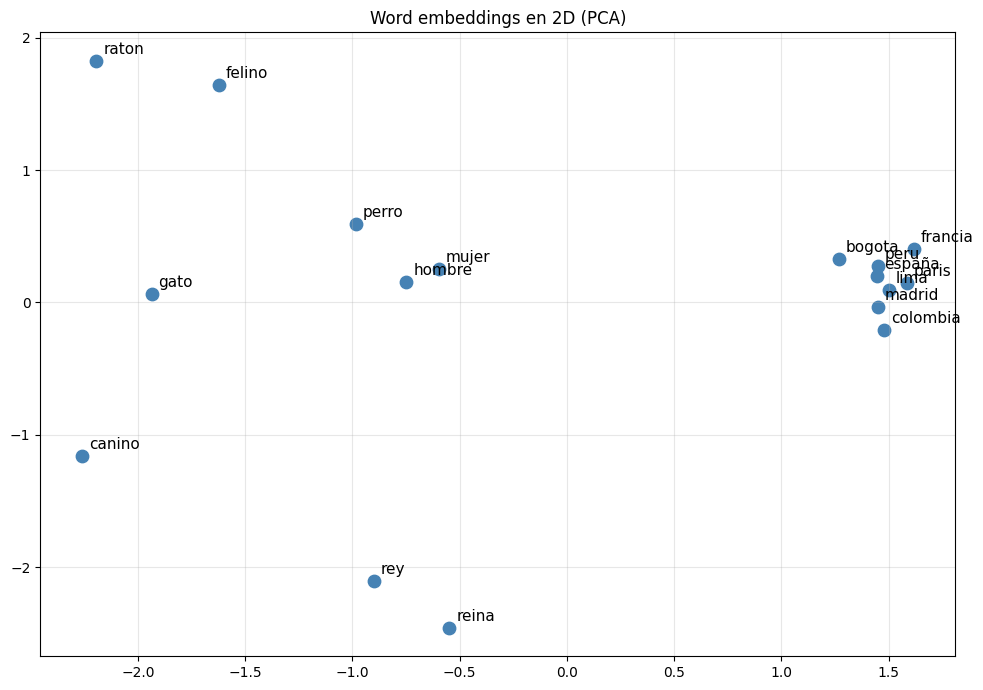

In [11]:
from sklearn.decomposition import PCA

palabras_interes = [
    'gato', 'perro', 'felino', 'canino', 'raton',
    'rey', 'reina', 'hombre', 'mujer',
    'madrid', 'paris', 'lima', 'bogota', 'españa', 'francia', 'peru', 'colombia',
]
validas = [p for p in palabras_interes if p in w2v.wv]
X = np.array([w2v.wv[p] for p in validas])
X2d = PCA(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(10, 7))
plt.scatter(X2d[:, 0], X2d[:, 1], s=80, color='steelblue')
for i, p in enumerate(validas):
    plt.annotate(p, (X2d[i, 0], X2d[i, 1]), fontsize=11,
                 xytext=(5, 5), textcoords='offset points')
plt.title('Word embeddings en 2D (PCA)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2.4 Limitaciones de los NLM

- **Embeddings estáticos**: "banco" tiene un único vector — mezcla "banco financiero" y "banco del parque".
- **RNN/LSTM** son secuenciales → paralelización pobre en GPU.
- Contexto efectivo limitado aunque mejor que n-gramas.

La solución: **contextualización** — que el embedding dependa de la oración.

---
## 3. PLM — Pre-trained Language Models

Paradigma **pre-training + fine-tuning**: entrena un modelo grande con tarea auto-supervisada sobre muchísimo texto y luego adáptalo a cualquier tarea con pocos datos.

Modelos icónicos:

- **ELMo** (2018): embeddings contextuales con biLSTM.
- **Transformer** (Vaswani et al., 2017): self-attention, paralelizable.
- **BERT** (2018): encoder con *Masked Language Modeling*.
- **GPT** (2018–19): decoder autoregresivo.

### 3.1 Embeddings contextuales con BERT

Vamos a ver cómo el vector de una palabra **cambia según el contexto** — algo que word2vec no puede hacer.

In [26]:
import torch
from transformers import AutoTokenizer, AutoModel

# Modelo pequeño multilingüe (~50MB)
MODEL_NAME = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()
print('Modelo cargado:', MODEL_NAME)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12091.18it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [27]:
def embedding_palabra(oracion, palabra):
    """Devuelve el embedding contextual de `palabra` dentro de `oracion`."""
    inputs = tokenizer(oracion, return_tensors='pt')
    with torch.no_grad():
        out = model(**inputs)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    # Buscar el primer sub-token que coincida con la palabra
    palabra_norm = palabra.lower()
    for i, tok in enumerate(tokens):
        tok_clean = tok.lstrip('▁').lower()
        if palabra_norm.startswith(tok_clean) and tok_clean:
            return out.last_hidden_state[0, i].numpy()
    return out.last_hidden_state[0, 0].numpy()

from numpy.linalg import norm
def cosine(a, b):
    return float(np.dot(a, b) / (norm(a) * norm(b) + 1e-12))

o1 = 'fui al banco a retirar dinero'
o2 = 'pague la hipoteca en el banco central'
o3 = 'me sente en el banco del parque a descansar'

v1 = embedding_palabra(o1, 'banco')
v2 = embedding_palabra(o2, 'banco')
v3 = embedding_palabra(o3, 'banco')

print(f"sim(banco_1 vs banco_2 [financiero]) = {cosine(v1, v2):.3f}")
print(f"sim(banco_1 vs banco_3 [mueble])     = {cosine(v1, v3):.3f}")
print(f"sim(banco_2 vs banco_3)              = {cosine(v2, v3):.3f}")

sim(banco_1 vs banco_2 [financiero]) = 0.824
sim(banco_1 vs banco_3 [mueble])     = 0.236
sim(banco_2 vs banco_3)              = 0.179


Los dos usos financieros de "banco" deberían estar más cerca entre sí que del "banco del parque". Esto es lo que **word2vec no podía hacer**.

### 3.2 Masked Language Modeling — la tarea de pre-entrenamiento de BERT

BERT aprende a **rellenar blancos** en un texto: le ocultamos una palabra y tiene que adivinarla.

In [28]:
from transformers import pipeline

fill = pipeline('fill-mask', model='dccuchile/bert-base-spanish-wwm-uncased')

for frase in [
    'el capital de francia es [MASK].',
    'mi perro se llama rex y es muy [MASK].',
    'el [MASK] es el mejor amigo del hombre.',
]:
    print(f'\n>>> {frase}')
    for pred in fill(frase, top_k=3):
        print(f"   {pred['token_str']:<15} p={pred['score']:.3f}")

Loading weights: 100%|██████████| 204/204 [00:00<00:00, 37648.52it/s]
BertForMaskedLM LOAD REPORT from: dccuchile/bert-base-spanish-wwm-uncased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



>>> el capital de francia es [MASK].
   paris           p=0.288
   francia         p=0.221
   france          p=0.065

>>> mi perro se llama rex y es muy [MASK].
   divertido       p=0.181
   bueno           p=0.096
   amable          p=0.061

>>> el [MASK] es el mejor amigo del hombre.
   amor            p=0.093
   aire            p=0.076
   hombre          p=0.047


### 3.3 GPT — generación autoregresiva

GPT predice el **siguiente token**, token a token. Usamos un modelo en español pequeño.

In [15]:
generador = pipeline('text-generation', model='datificate/gpt2-small-spanish')

prompt = 'La inteligencia artificial es'
salidas = generador(prompt, max_length=50, num_return_sequences=2, do_sample=True,
                    top_k=50, top_p=0.95, temperature=0.9)

for i, s in enumerate(salidas):
    print(f"--- muestra {i+1} ---")
    print(s['generated_text'])
    print()

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 30455.72it/s]
GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Error while downloading from https://huggingface.co/api/resolve-cache/models/datificate/gpt2-small-spanish/02e3092372e8a8b20c64e29350a024a998a7c00d/vocab.json: The read operation timed out
Trying to resume download...
Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length', 'top_p', 'top_k', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `m

--- muestra 1 ---
La inteligencia artificial es muy útil en el diseño de sistemas de comunicaciones, como el sistema de navegación, control de la velocidad de los misiles, y la comunicación entre dispositivos móviles.

El uso de este dispositivo permite a un equipo de guerra electrónica diseñar sistemas para el control de armas nucleares que pueden ser utilizados en situaciones con características nucleares. El concepto de combate de naves de guerra electrónica en los años 70 del siglo XX dio lugar a la introducción del radar, que en la época era totalmente obsoleto. Los sistemas de guerra electrónica incluyen sistemas de radar electrónicos para los ataques nucleares y para la defensa en áreas convencionales de los misiles nucleares, así como sistemas de protección en los campos electromagnéticos.

El desarrollo y desarrollo de sistemas de defensa se ha caracterizado por la utilización de sistemas de defensa avanzados. Las armas nucleares se han utilizado para realizar ejercicios de pr

### 3.4 Encoder vs Decoder vs Encoder-Decoder

| Arquitectura | Objetivo | Ejemplos | Fuerte en |
|--------------|----------|----------|-----------|
| **Encoder** | Masked LM | BERT, RoBERTa, DeBERTa, BETO | comprensión, clasificación, NER |
| **Decoder** | Next token | GPT, LLaMA, Mistral | generación, diálogo |
| **Enc-Dec** | Seq2Seq | T5, BART, mT5 | traducción, resumen |

---
## 4. LLM — Large Language Models

Son PLMs **a una escala que revela fenómenos nuevos**:

- **Emergent abilities**: capacidades que aparecen "de golpe" al cruzar cierto tamaño (razonamiento multi-paso, aritmética, traducción zero-shot).
- **In-context learning**: aprender de ejemplos en el prompt sin actualizar pesos.

### 4.1 Few-shot prompting

Le damos al modelo ejemplos dentro del prompt. El modelo **nunca fue entrenado** específicamente para la tarea, pero aprende del patrón.

In [16]:
prompt_few_shot = (
    'Traduce al ingles:\n'
    '\n'
    'Español: el gato come pescado\n'
    'English: the cat eats fish\n'
    '\n'
    'Español: la mujer lee un libro\n'
    'English: the woman reads a book\n'
    '\n'
    'Español: el perro duerme en el sofa\n'
    'English:'
)

salida = generador(prompt_few_shot, max_length=120, num_return_sequences=1,
                   do_sample=False)[0]['generated_text']
print(salida)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'do_sample', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Traduce al ingles:

Español: el gato come pescado
English: the cat eats fish

Español: la mujer lee un libro
English: the woman reads a book

Español: el perro duerme en el sofa
English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el gato come pescado

English: the woman reads a book

Español: el


> Este modelo (GPT-2 pequeño en español) es muy limitado — GPT-3/4/Claude lo harían sin dudar. La **escala** es lo que hace que el in-context learning funcione de verdad.

### 4.2 Por qué la escala importa

Wei et al. (2022) documentaron capacidades emergentes: tareas donde modelos pequeños fallan cerca del azar y modelos grandes, de pronto, las resuelven.

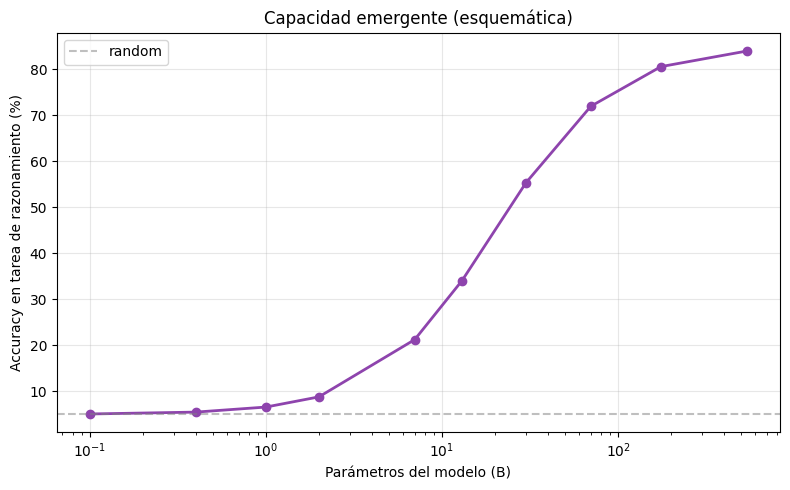

In [17]:
# Curva ilustrativa de capacidad emergente (esquemática, no datos reales)
params_B = np.array([0.1, 0.4, 1, 2, 7, 13, 30, 70, 175, 540])  # escala de parámetros en B
# Capacidad emergente: salto abrupto alrededor de cierta escala
def emergente(n, k=1.5, n0=10):
    return 1 / (1 + np.exp(-k * (np.log10(n) - np.log10(n0))))
perf = emergente(params_B * 1e9, k=3, n0=20e9) * 80 + 5  # escalado para que se vea

plt.figure(figsize=(8, 5))
plt.plot(params_B, perf, marker='o', lw=2, color='#8e44ad')
plt.xscale('log')
plt.xlabel('Parámetros del modelo (B)')
plt.ylabel('Accuracy en tarea de razonamiento (%)')
plt.title('Capacidad emergente (esquemática)')
plt.axhline(5, color='gray', ls='--', alpha=0.5, label='random')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 4.3 Modelos clave de la era LLM

| Modelo | Año | Params | Datos (tokens) | Aporte |
|--------|-----|--------|----------------|--------|
| GPT-3 | 2020 | 175B | 300B | popularizó few-shot |
| Chinchilla | 2022 | 70B | 1.4T | compute-optimal |
| LLaMA 2 | 2023 | 7–70B | 2T | open weights |
| GPT-4 | 2023 | ? | ? | multimodal |
| Mistral / Mixtral | 2023–24 | 7B–8×22B | ? | MoE abierto |
| Claude 3/4 | 2024–25 | ? | ? | razonamiento, contexto largo |

Más detalles en el `.md` complementario.

---

## Recursos y siguientes pasos

El archivo `evolucion_modelos_lenguaje.md` en esta misma carpeta contiene todas las referencias con enlaces: papers originales de BERT, GPT, ELMo, Word2Vec, Transformer, surveys y cursos.

### Para profundizar

- **Scaling laws** — dedicamos un notebook entero: `../04_scaling_laws/04_scaling_laws.ipynb`. Incluye derivación del compute-optimal frontier, ley KM vs Chinchilla, verificación empírica a pequeña escala y calculadora práctica.
- **Deep learning aplicado** — `../03_deep_learning_nlp/03_deep_learning_nlp.ipynb`: RNN, LSTM y autoencoder entrenados sobre *Don Quijote* para generación de texto.